In [1]:
import sys
sys.path.insert(0, '..')

In [2]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib
import chainconsumer as cc


%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from fisher import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import jax.tree_util as jtu
import interpax as ipx

def set_array(pytree):
    dtype = np.float64 if jax.config.x64_enabled else np.float32
    floats, other = eqx.partition(pytree, eqx.is_inexact_array_like)
    floats = jtu.tree_map(lambda x: np.array(x, dtype=dtype), floats)
    return eqx.combine(floats, other)

In [4]:
wid = 64
oversample = 4

nwavels = 3#13#6
npoly=1#10#2

n_zernikes = 20#30#12

optics = NICMOSSecondaryFresnelOptics(512, wid, oversample, mag=3.3, defocus=0., despace=0., n_zernikes = n_zernikes)

detector = NICMOSDetector(oversample, wid)

ddir = "../data/MAST_2024-09-22T03_37_01.724Z/HST/"

basis_file = np.load("spectrum_basis.npy")[:,:npoly]

spectrum_basis = ipx.interp1d(np.linspace(0,1,nwavels), np.linspace(0,1,basis_file.shape[0]), basis_file)
spectrum_basis = spectrum_basis/np.sqrt(np.mean(spectrum_basis**2, axis=0))



ddir = "../data/MAST_2025-03-06T11_35_52.340Z/HST/"


exposures_single = [
    #exposure_from_file(ddir + "n4be04sqq_cal.fits", SinglePointFit(spectrum_basis, "F110M"), crop=wid),
    #exposure_from_file(ddir + "n4be02nqq_cal.fits", SinglePointFit(spectrum_basis, "F145M"), crop=wid),
    #exposure_from_file(ddir + "n4be02nrq_cal.fits", SinglePointFit(spectrum_basis, "F110M"), crop=wid),
    exposure_from_file(ddir + "n4be02nqq_cal.fits", SinglePointFit(spectrum_basis, "F145M"), crop=wid),
    exposure_from_file(ddir + "n4be02nrq_cal.fits", SinglePointFit(spectrum_basis, "F165M"), crop=wid),
    #exposure_from_file(ddir + "n4be06bzq_cal.fits", SinglePointFit(spectrum_basis, "F110M"), crop=wid),
    ]

ddir = "../data/MAST_2024-09-08T07_59_18.213Z/HST/"

files = [
    # F095N
    "n43ca5fjq_cal.fits",
    "n43ca5fkq_cal.fits",
    "n43ca5flq_cal.fits",
    "n43ca5fmq_cal.fits",
    #F190N
    "n43ca5feq_cal.fits",
    "n43ca5ffq_cal.fits",
    "n43ca5fgq_cal.fits",
    "n43ca5fhq_cal.fits",
    #F187N
    #"n43c03dnq_cal.fits",
    #"n43c03doq_cal.fits",
    #"n43c03dpq_cal.fits",
    #"n43c03drq_cal.fits",
    #F108N
    #"n43c03dsq_cal.fits",
    #"n43c03duq_cal.fits",
    ##"n43c03dvq_cal.fits",
    ##"n43c03dwq_cal.fits",
][-1:]

exposures_single = [
    exposure_from_file(ddir + "n43ca5fhq_cal.fits", SinglePointFit(spectrum_basis, "F190N"), crop=wid),
    #exposure_from_file(ddir + "n43c03dsq_cal.fits", SinglePointFit(spectrum_basis, "F108N"), crop=wid),
    ]



100 71
100 71
124 52


/Users/haydengreer/UQ/Subjects/Semester 2 2024/PHYS3900/hubble/notebooks/../models.py:163: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, tf(data), tf(err_with_poisson), tf(bad_with_poisson), fit, mjd, exptime, wcs, pam)
/Users/haydengreer/UQ/Subjects/Semester 2 2024/PHYS3900/hubble/notebooks/../models.py:163: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, tf(data), tf(err_with_poisson), tf(bad_with_poisson), fit, mjd, exptime, wcs, pam)
/Users/haydengreer/UQ/Subjects/Semester 2 2024/PHYS3900/hubble/notebooks/../models.py:163: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, tf(data), tf(err_with_poisson), tf(bad_with_poisson), fit, mjd, exptime, wc

In [5]:
for e in exposures_single:
    print(e.mjd)#*86400)
    print(e.target)
    print(e.filter)
    print(e.exptime)

50934.93448622
SAO179809-PSF
F190N
19.93641


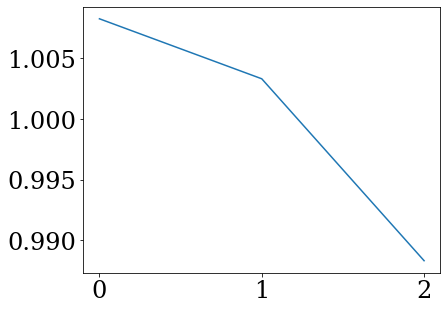

In [6]:
plt.plot(spectrum_basis[:, :5])

In [7]:
params = {
    #"fluxes": {},
    "positions": {},
    "spectrum": {},
    "aberrations": {},

    #"rot": 0.,

    "cold_mask_shift": {},
    "cold_mask_rot": {},
    "cold_mask_scale": {},
    "cold_mask_shear": {},
    "primary_scale": {},
    "primary_rot": {},
    "primary_shear": {},
    "outer_radius": 1.2*0.955,
    "secondary_radius": 0.372*1.2,
    "spider_width": 0.077*1.2,

    "softening": 2.,#0.1,
    "bias": {},
    "jitter": {},

    "defocus": {},#1e5#{}
    "despace": {},
    "mag": 3.3,
}

positions = [[0.,0.,],[0.,0.,],[0.,0.,],[0.,0.,]]#[[0.43251792, 0.33013815],[ 0.49417186, -0.5629123 ]]


for idx, exp in enumerate(exposures_single):
    params["positions"][exp.fit.get_key(exp, "positions")] = np.asarray([0.,0.])#positions_dict[exp.fit.get_key(exp, "positions")]#np.asarray(positions[idx])#np.asarray([0.49162114, -0.5632928])#np.asarray([ 0.45184505, -0.8391668 ])#np.asarray([-0.2,0.4])
    params["spectrum"][exp.fit.get_key(exp, "spectrum")] = (np.zeros(npoly)).at[0].set(np.log10(np.nansum(exp.data)/nwavels))#np.asarray([-1.03646245, -0.29984712, -0.14137265, -0.04618831, -0.05788671, -0.02545625,
 #-0.03688181,  0.0231736,   0.02356589, -0.00177967]).at[0].set(np.log10(np.nansum(exp.data)/nw[idx]))#np.zeros(nspec[idx]).at[0].set(1)*np.log10(np.nansum(exp.data)/nw[idx])#np.ones(npoly)*np.log10(np.nansum(exp.data)/nwavels)#(np.zeros(npoly)).at[0].set(1)*np.log10(np.nansum(exp.data)/nwavels)
    params["aberrations"][exp.fit.get_key(exp, "aberrations")] = np.asarray([ 21.9267203 , -14.20133333, -27.77798078, -28.44491861,
          -5.48501933,  -8.87418317,  23.78868922,   7.46177568,
          -0.2863787 , -13.39340241,  -4.89880687,   4.25452262,
          -4.49137758,   3.42268926,   4.09896897,  -3.15079696,
           1.90339653,  -5.20437772,   5.11727282,   1.82359044])#np.zeros(n_zernikes)#np.asarray([0., 24.884588  , -25.489779  , -17.15699   , -21.790146  ,
    #      -4.592212  ,  -4.832893  ,  19.196083  ,   0.37983412,
    #       7.0756216 ,   0.30277824,  -6.330534])#np.zeros(n_zernikes)
    params["cold_mask_shift"][exp.fit.get_key(exp, "cold_mask_shift")] = np.asarray([8.,8.])#np.asarray([9.599048, 6.196583])
    params["cold_mask_rot"][exp.fit.get_key(exp, "cold_mask_rot")] = -45.
    params["cold_mask_scale"][exp.fit.get_key(exp, "cold_mask_scale")] = np.asarray([1.,1.])
    params["cold_mask_shear"][exp.fit.get_key(exp, "cold_mask_shear")] = np.asarray([0.,0.])
    params["primary_rot"][exp.fit.get_key(exp, "primary_rot")] = -45. + 90. 
    params["primary_scale"][exp.fit.get_key(exp, "primary_scale")] = np.asarray([1.,1.])
    params["primary_shear"][exp.fit.get_key(exp, "primary_shear")] = np.asarray([0.,0.])
    params["defocus"][exp.fit.get_key(exp, "defocus")] = 0.#-0.233#2.4#800.#160.*20
    params["despace"][exp.fit.get_key(exp, "despace")] = 0.#2.4#800.#160.*20
    

    params["bias"][exp.fit.get_key(exp, "bias")] = 0.
    params["jitter"][exp.fit.get_key(exp, "jitter")] = 7/43*oversample


model_single = set_array(NICMOSModel(exposures_single, params, optics, detector))
#model_binary = set_array(NICMOSModel(exposures_binary, params, optics, detector))


params = ModelParams(params)

In [8]:
print(np.nansum(exp.data))

30113.134484296388


In [9]:
np.log10(7336/np.sum(10**spectrum_basis[:,0]))

Array(2.38829144, dtype=float64)

In [10]:
print(params.params)

{'positions': {'n43ca5fhq': Array([0., 0.], dtype=float64)}, 'spectrum': {'SAO179809-PSF_F190N': Array([4.00163471], dtype=float64)}, 'aberrations': {'n43ca5fhq': Array([ 21.9267203 , -14.20133333, -27.77798078, -28.44491861,
        -5.48501933,  -8.87418317,  23.78868922,   7.46177568,
        -0.2863787 , -13.39340241,  -4.89880687,   4.25452262,
        -4.49137758,   3.42268926,   4.09896897,  -3.15079696,
         1.90339653,  -5.20437772,   5.11727282,   1.82359044],      dtype=float64)}, 'cold_mask_shift': {'global': Array([8., 8.], dtype=float64)}, 'cold_mask_rot': {'global': -45.0}, 'cold_mask_scale': {'global': Array([1., 1.], dtype=float64)}, 'cold_mask_shear': {'global': Array([0., 0.], dtype=float64)}, 'primary_scale': {'global': Array([1., 1.], dtype=float64)}, 'primary_rot': {'global': 45.0}, 'primary_shear': {'global': Array([0., 0.], dtype=float64)}, 'outer_radius': 1.146, 'secondary_radius': 0.44639999999999996, 'spider_width': 0.0924, 'softening': 2.0, 'bias': {'n43

In [11]:
exp.fit.source.set("spectrum.basis_weights", np.array([0.]))

PointSource(
  spectrum=CombinedBasisSpectrum(
    wavelengths=f64[3],
    filt_weights=f64[3],
    basis_weights=f64[1],
    basis_vects=f64[3,1]
  ),
  position=f64[2],
  flux=1.0
)

18.613670660736286


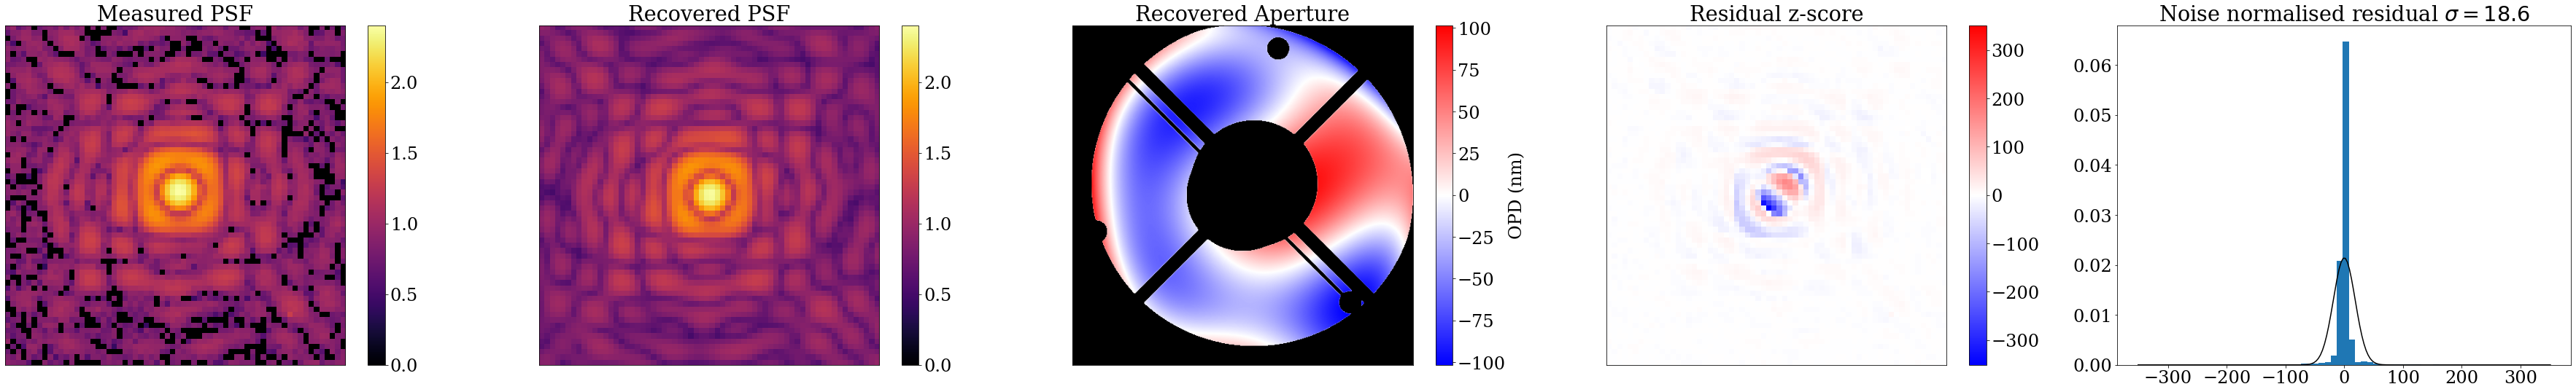

In [12]:
plot_comparison(model_single, params, exposures_single)

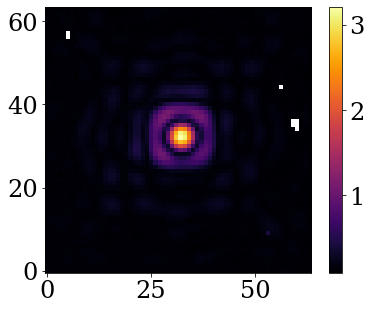

In [13]:
plt.imshow(exposures_single[0].err)
plt.colorbar()

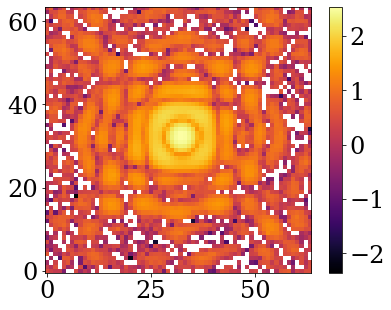

In [14]:
plt.imshow(np.log10(exposures_single[0].data/exposures_single[0].err))
plt.colorbar()

In [15]:
print(exposures_single[0].exptime)

19.93641


([], [])

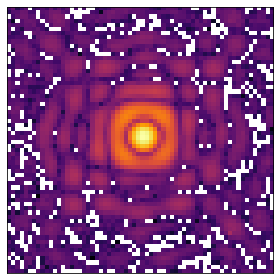

In [16]:
plt.imshow(exposures_single[0].data**0.125)
plt.xticks([])
plt.yticks([])

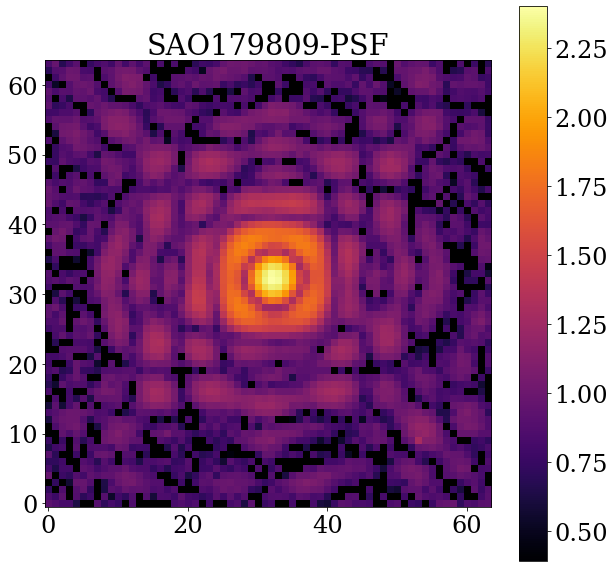

In [17]:
cmap = matplotlib.colormaps['inferno']
cmap.set_bad('k',1)
plt.figure(figsize=(10,10))
plt.imshow(exposures_single[0].data**0.125, cmap=cmap)
plt.title(exposures_single[0].target)
plt.colorbar()


In [18]:
def scheduler(lr, start, *args):
    shed_dict = {start: 1e10}
    for start, mul in args:
        shed_dict[start] = mul
    return optax.piecewise_constant_schedule(lr / 1e10, shed_dict)

base_sgd = lambda vals: optax.sgd(vals, nesterov=True, momentum=0.6)

opt = lambda lr, start, *schedule: base_sgd(scheduler(lr, start, *schedule))

base_sgd2 = lambda vals: optax.noisy_sgd(vals)

opts = lambda lr, start, *schedule: base_sgd2(scheduler(lr, start, *schedule))


base_adam = lambda vals: optax.adam(vals)
opta = lambda lr, start, *schedule: base_adam(scheduler(lr, start, *schedule))





def flatten(l):
    if isinstance(l, (tuple, list)):
         return [a for i in l for a in flatten(i)]
    else:
        return [l]



g = 5e-2

things = {
    "positions": opt(g*5, 0),
    "spectrum": opt(g*1, 10),#opt(g*2, 10),#opt(g*2, 10),#, (20, 1.5)),
    "cold_mask_shift": opt(g*5, 30),
    
    "bias": opt(g*3, 20),
    "aberrations": opt(g*0.1, 80),
    #"jitter": opt(g*1, 120),

    "despace": opt(g*0.8, 50),
    "mag": opt(g*10, 100),

    #"cold_mask_scale": opt(g*0.1, 100),
    "cold_mask_shear": opt(g*0.1, 100),
    #"primary_scale": opt(g*1, 100),
    #"primary_shear": opt(g*1, 100),
}

things_start = {
    "positions": opt(g*5, 0),
}

groups = list(things.keys())

In [19]:
initial_losses, initial_models = optimise(params, model_single, exposures_single, things_start, 10, recalculate=True)

Calculating Fishers


  0%|          | 0/1 [00:00<?, ?it/s]

(Array([-4.39561289e-07, -3.75408319e-07], dtype=float64), <jax._src.util.HashablePartial object at 0x1317ada90>)
Fitting Model


  0%|          | 0/10 [00:00<?, ?it/s]

In [20]:
params

ModelParams(
  params={
    'positions': {'n43ca5fhq': f64[2]},
    'spectrum': {'SAO179809-PSF_F190N': f64[1]},
    'aberrations': {'n43ca5fhq': f64[20]},
    'cold_mask_shift': {'global': f64[2]},
    'cold_mask_rot': {'global': -45.0},
    'cold_mask_scale': {'global': f64[2]},
    'cold_mask_shear': {'global': f64[2]},
    'primary_scale': {'global': f64[2]},
    'primary_rot': {'global': 45.0},
    'primary_shear': {'global': f64[2]},
    'outer_radius': 1.146,
    'secondary_radius': 0.44639999999999996,
    'spider_width': 0.0924,
    'softening': 2.0,
    'bias': {'n43ca5fhq': 0.0},
    'jitter': {'n43ca5fhq': 0.6511627906976745},
    'defocus': {'n43ca5fhq': 0.0},
    'despace': {'n43ca5fhq': 0.0},
    'mag': 3.3
  }
)

In [21]:
params_stripped = ModelParams({})

3.2588114211410364


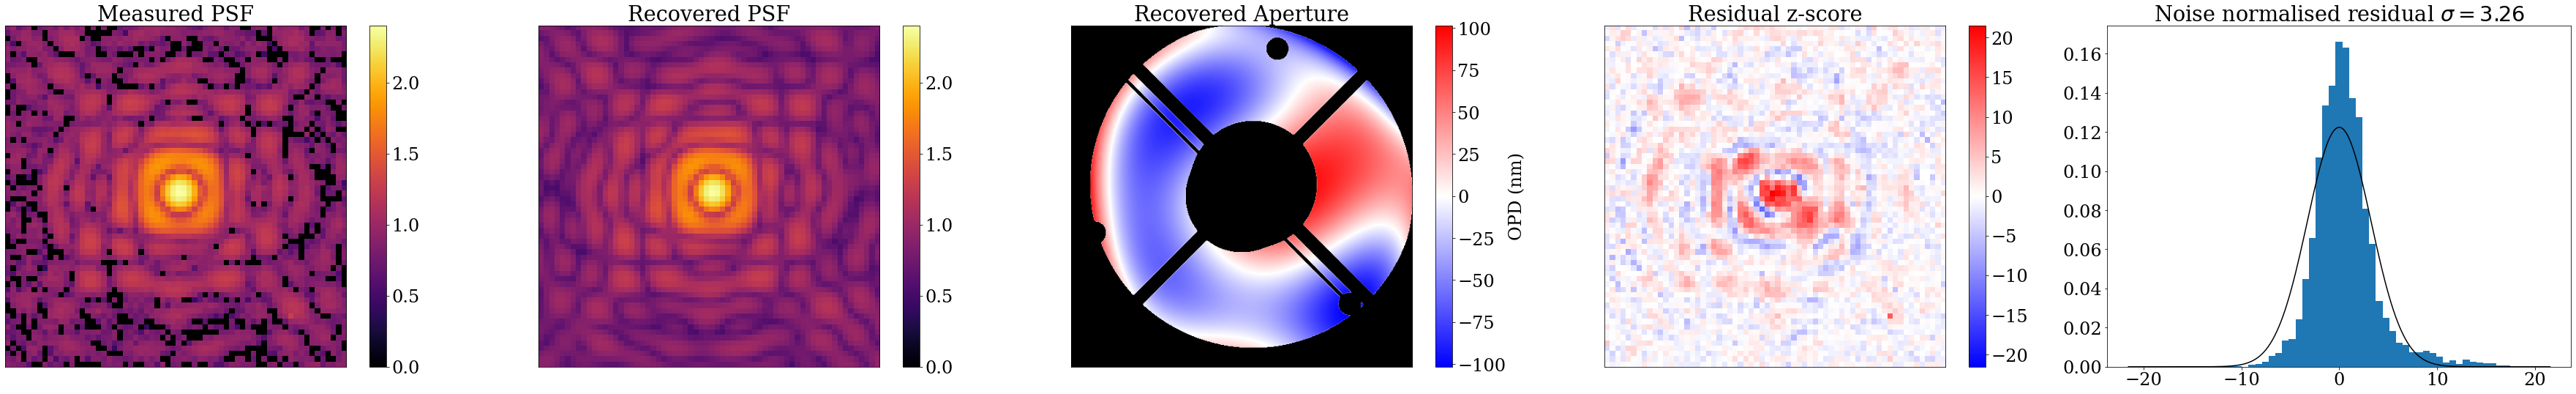

In [22]:
plot_comparison(model_single, initial_models[-1], exposures_single)

In [23]:
initial_models[-1].params

{'positions': {'n43ca5fhq': Array([-0.60200885, -0.75223994], dtype=float64)}}

In [24]:
orig_params = initial_models[-1].inject(params).params
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things})

In [25]:
orig_params = initial_models[-1].inject(params).params

In [26]:
opt_params

{'aberrations': {'n43ca5fhq': Array([ 21.9267203 , -14.20133333, -27.77798078, -28.44491861,
          -5.48501933,  -8.87418317,  23.78868922,   7.46177568,
          -0.2863787 , -13.39340241,  -4.89880687,   4.25452262,
          -4.49137758,   3.42268926,   4.09896897,  -3.15079696,
           1.90339653,  -5.20437772,   5.11727282,   1.82359044],      dtype=float64)},
 'bias': {'n43ca5fhq': Array(0., dtype=float64)},
 'cold_mask_shear': {'global': Array([0., 0.], dtype=float64)},
 'cold_mask_shift': {'global': Array([8., 8.], dtype=float64)},
 'despace': {'n43ca5fhq': Array(0., dtype=float64)},
 'mag': Array(3.3, dtype=float64),
 'positions': {'n43ca5fhq': Array([-0.60200885, -0.75223994], dtype=float64)},
 'spectrum': {'SAO179809-PSF_F190N': Array([4.00163471], dtype=float64)}}

In [27]:
losses, models = optimise(initial_models[-1].inject(params), initial_models[-1].inject(model_single), exposures_single, things, 500, recalculate=True)
#losses, models = optimise(params, model_single, exposures_single, things, 150, recalculate=False)

Calculating Fishers


  0%|          | 0/1 [00:00<?, ?it/s]

(Array([-1.15971335e-01, -9.99767771e-02, -1.86166010e-02, -1.69354670e-02,
       -1.48834979e-02, -1.50810546e-02, -7.13471399e-02, -4.91787092e-02,
       -6.23060708e-02, -9.98047836e-02, -1.14167001e-01, -3.06507283e-02,
       -3.28805320e-02, -1.65035323e-02, -1.60074890e-02, -2.84933281e-02,
       -2.82262118e-02, -8.10195258e-02, -9.16814501e-02, -5.15199622e-02,
       -4.91805307e-06, -1.12736237e-04, -1.09720754e-04, -1.38154416e-04,
       -1.35830690e-04, -2.46288490e-03, -1.32516273e-07, -8.14507609e-07,
       -7.83243974e-07, -7.57604867e-08], dtype=float64), <jax._src.util.HashablePartial object at 0x13142fce0>)
Fitting Model


  0%|          | 0/500 [00:00<?, ?it/s]

In [28]:
losses, params_history = optimise_new(opt_params, initial_models[-1].inject(model_single), exposures_single, things, 500)

[1.15971335e-01 9.99767771e-02 1.86166010e-02 1.69354670e-02
 1.48834979e-02 1.50810546e-02 7.13471399e-02 4.91787092e-02
 6.23060708e-02 9.98047836e-02 1.14167001e-01 3.06507283e-02
 3.28805320e-02 1.65035323e-02 1.60074890e-02 2.84933281e-02
 2.82262118e-02 8.10195258e-02 9.16814501e-02 5.15199622e-02
 4.91805307e-06 1.12736237e-04 1.09720754e-04 1.38154416e-04
 1.35830690e-04 2.46288490e-03 1.32516273e-07 8.14507609e-07
 7.83243974e-07 7.57604867e-08]


  0%|          | 0/500 [00:00<?, ?it/s]

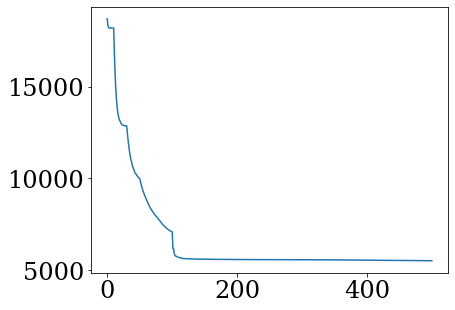

In [29]:
plt.plot(losses[:])

In [30]:
print(losses[0], losses[-1])

18689.886086809325 5522.699287743111


In [31]:
#stop

8
2.127144990456967


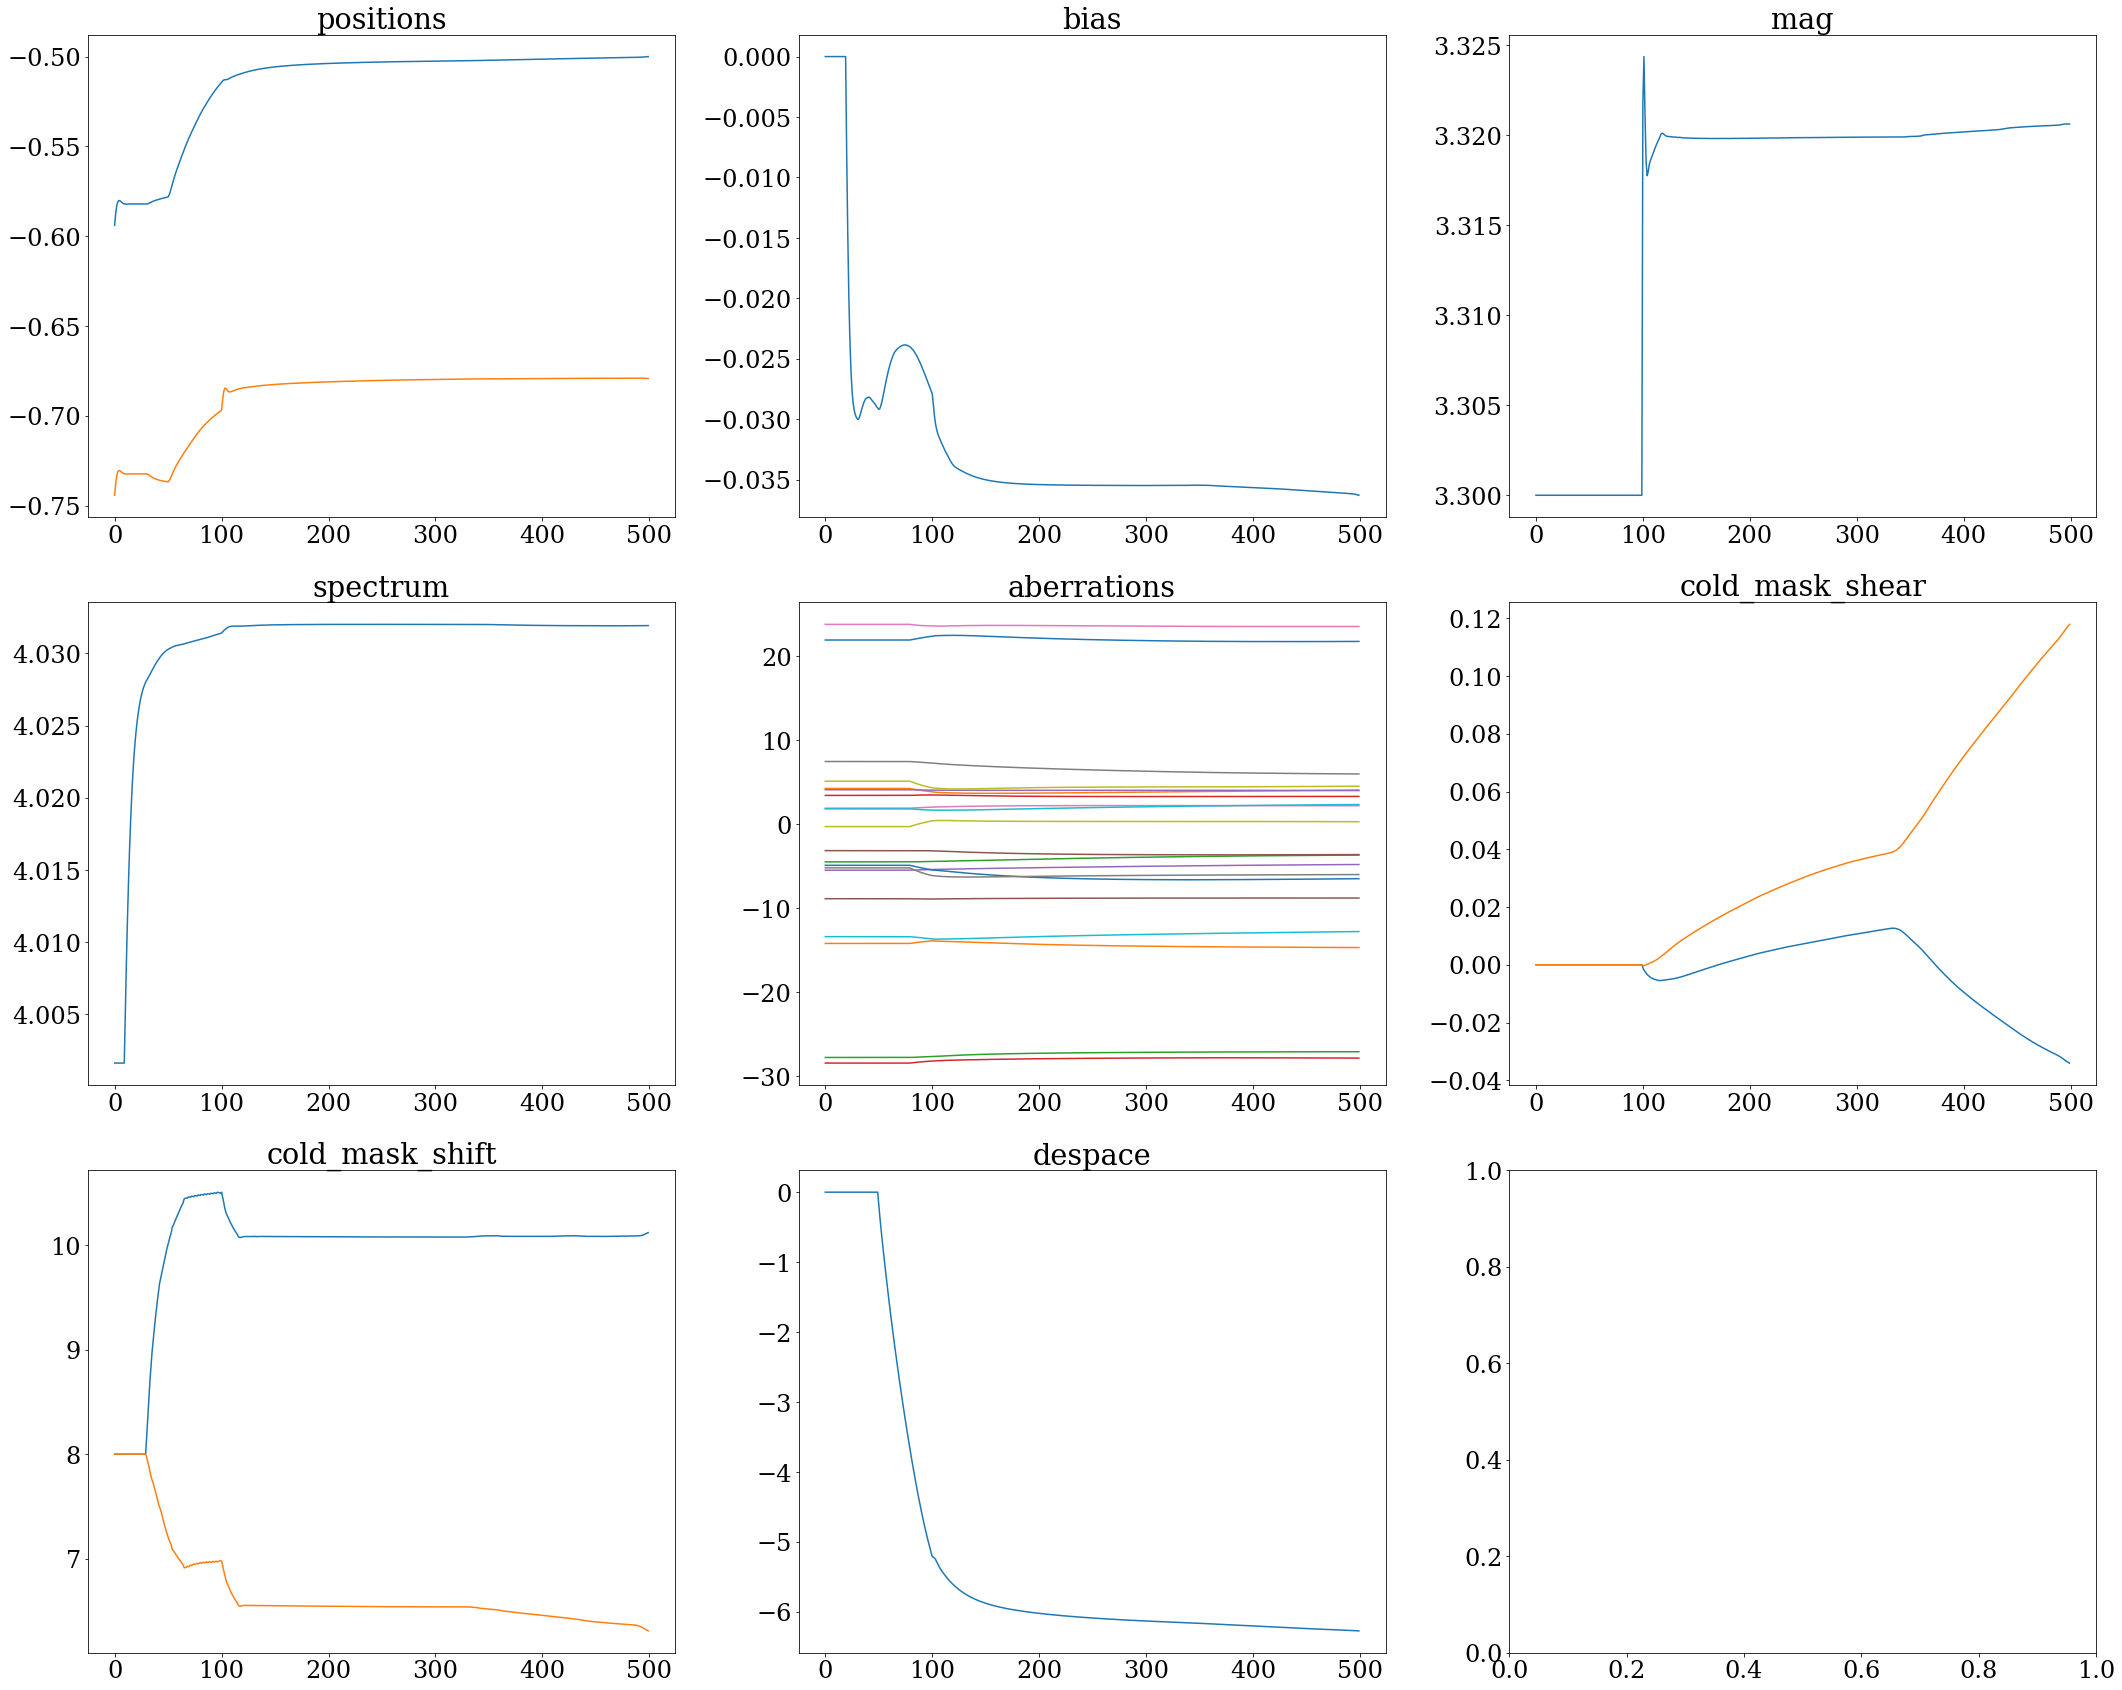

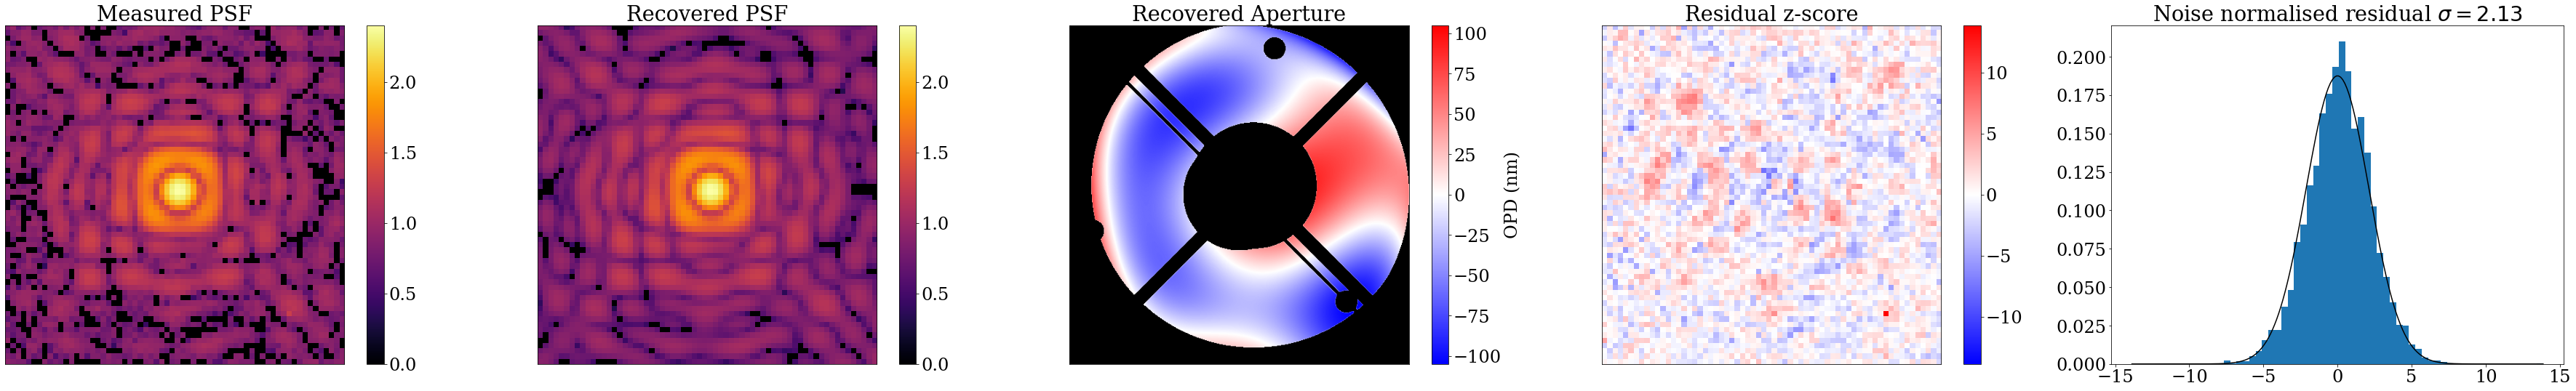

In [32]:
plot_params(params_history, groups, xw = 3)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single)

In [34]:
final_params = optimise_optimistix(params_history[-1], model_single, exposures_single)

In [35]:
final_params

ModelParams(
  params={
    'aberrations': {'n43ca5fhq': f64[20]},
    'bias': {'n43ca5fhq': f64[]},
    'cold_mask_shear': {'global': f64[2]},
    'cold_mask_shift': {'global': f64[2]},
    'despace': {'n43ca5fhq': f64[]},
    'mag': f64[],
    'positions': {'n43ca5fhq': f64[2]},
    'spectrum': {'SAO179809-PSF_F190N': f64[1]}
  }
)

In [36]:
#sol.stats

2.1103068883818077


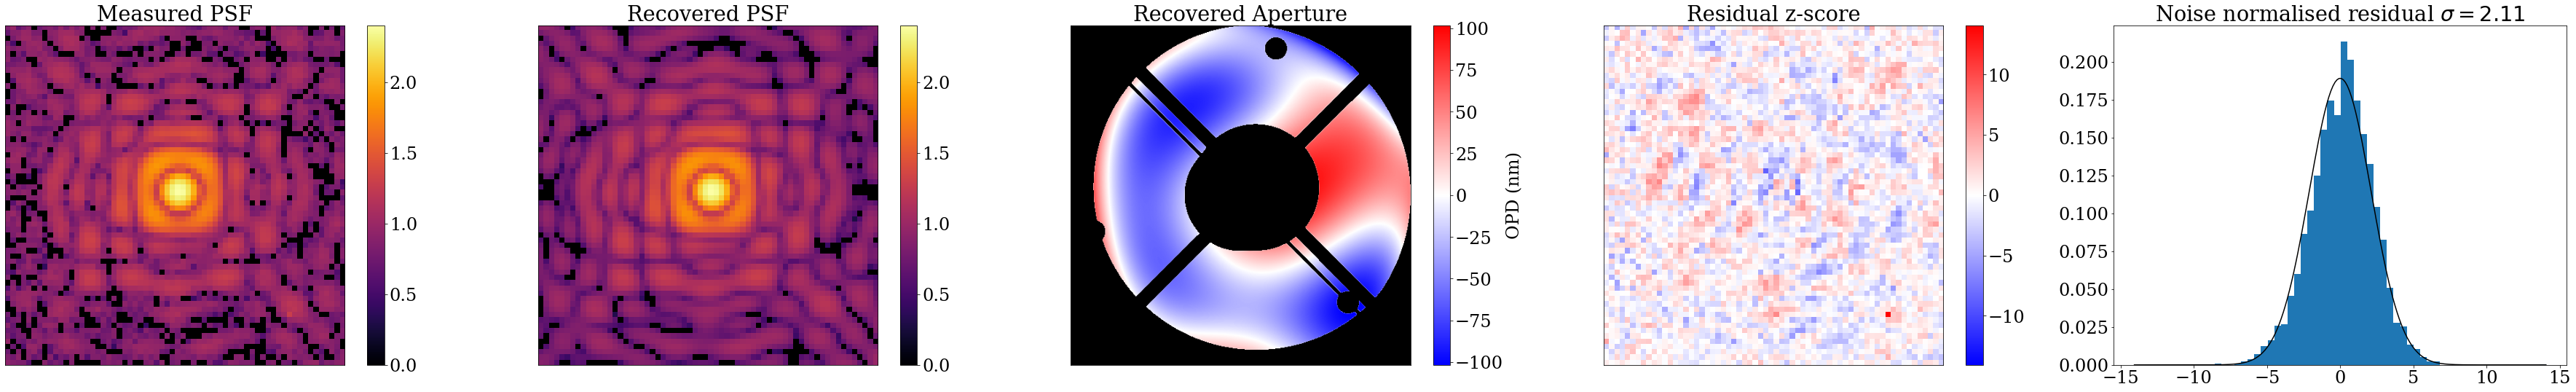

In [37]:
plot_comparison(final_params.inject((model_single)), final_params, exposures_single)

In [38]:
from mpl_toolkits.axes_grid1 import make_axes_locatable


2.1103068883818077


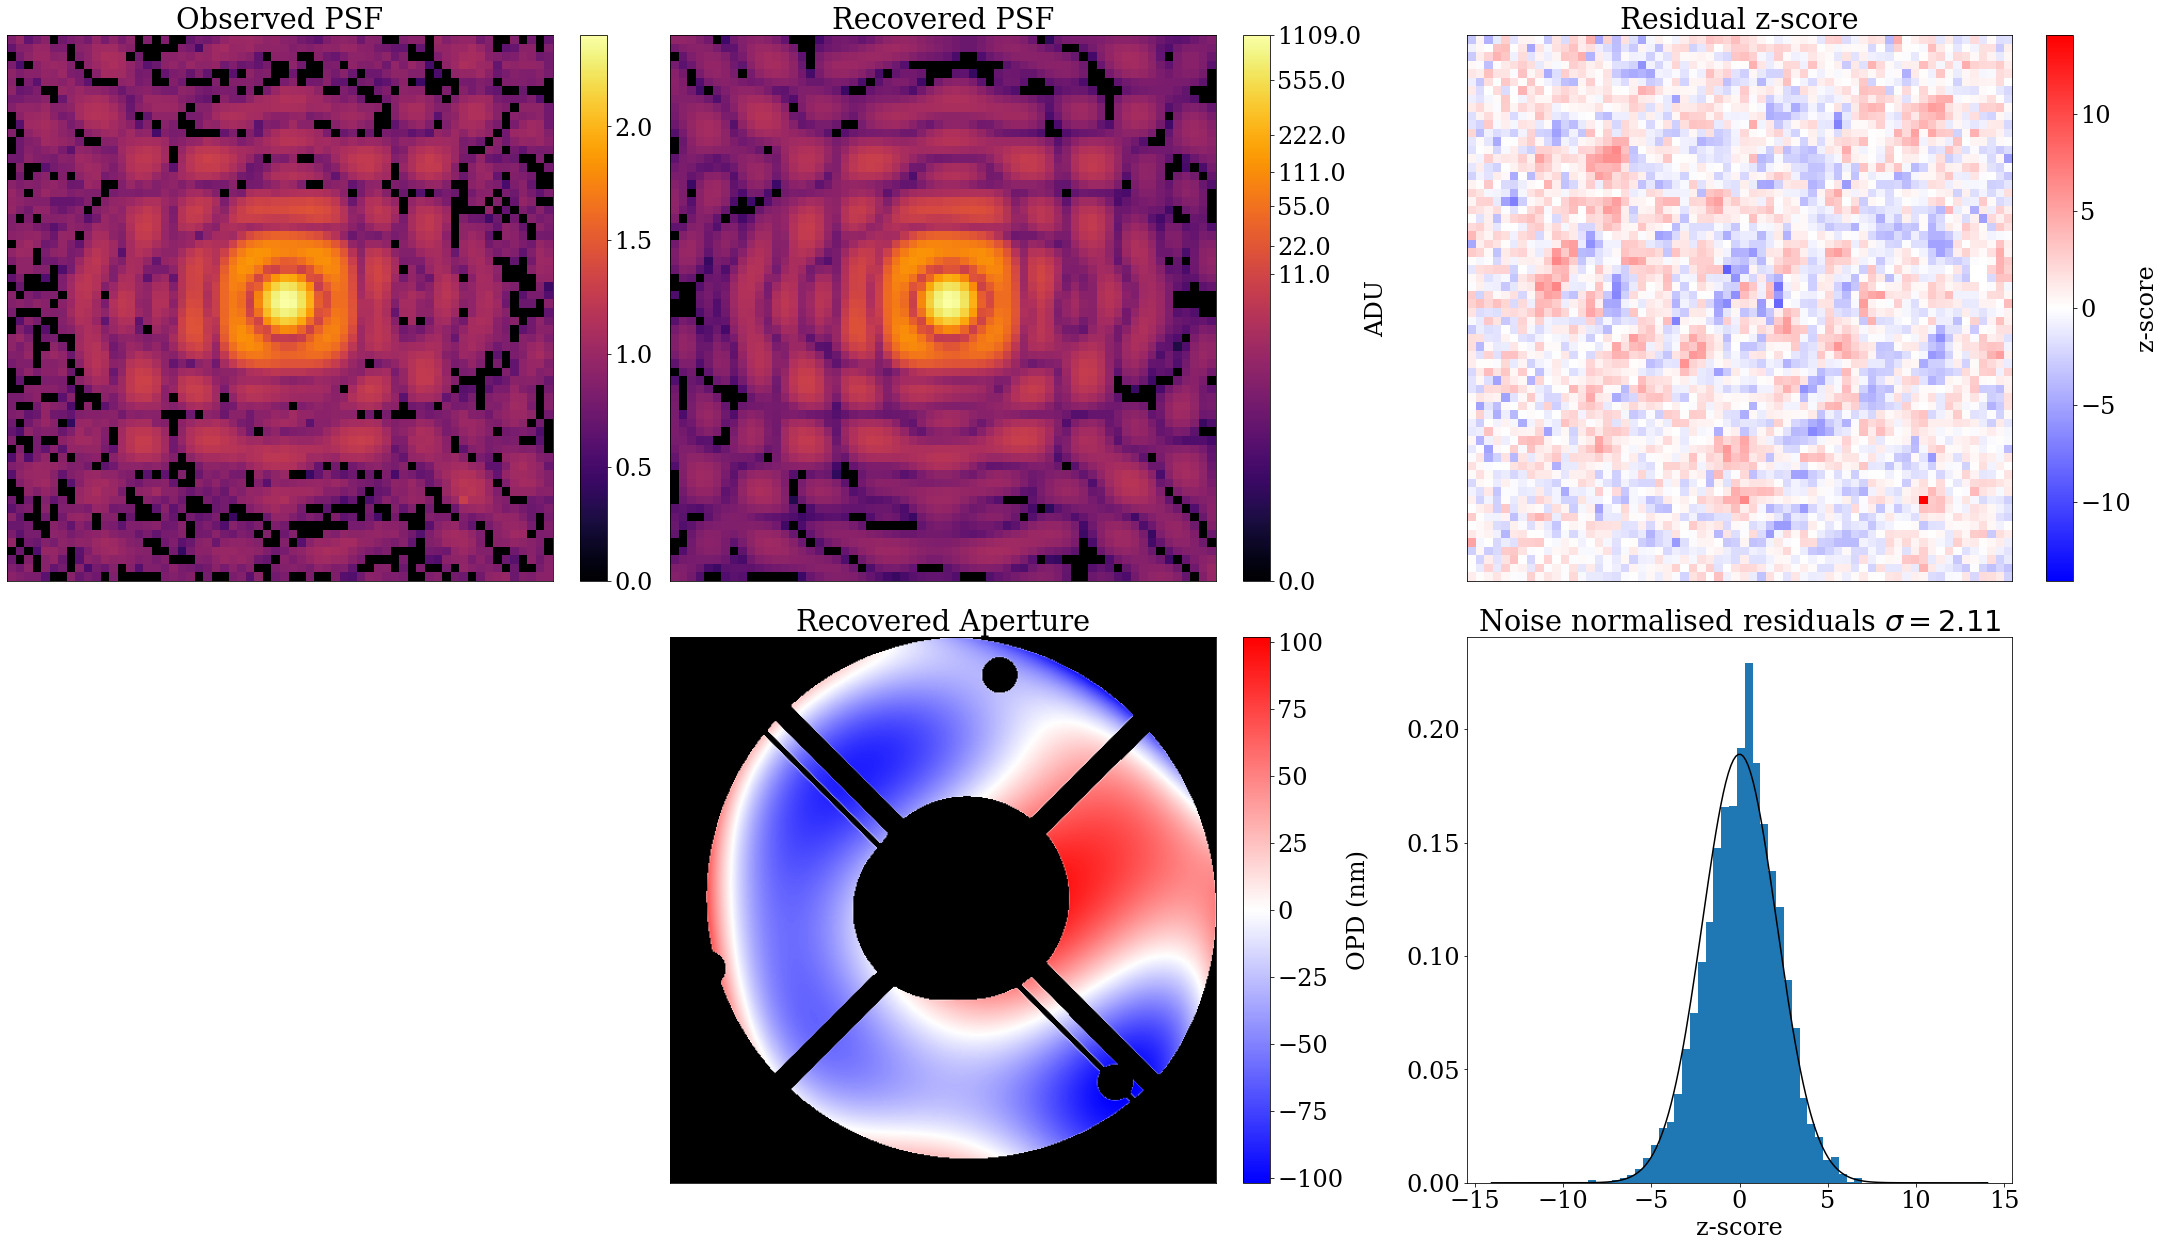

In [39]:
exp = exposures_single[0]
fig, axs = plt.subplots(2,3, figsize=(30,20), layout='compressed')
graticule = False
save=False

cmap = matplotlib.colormaps['inferno']
cmap.set_bad('k',1)



model = final_params.inject((model_single))

coords = dlu.pixel_coords(512, 2.4)
cropped_frame = exp.data**0.125

fit = exp.fit(model, exp)

wid = fit.shape[0]

telescope_frame = fit**0.125

vm = max(np.nanmax(cropped_frame),np.nanmax(telescope_frame))
cd=axs[0, 0].imshow(cropped_frame, vmin=0,vmax=vm,cmap=cmap)
plt.colorbar(cd,ax=axs[0,0])

if graticule:
    axs[0, 0].axvline((wid-1)/2 + params.get(exp.map_param("positions"))[0], color='k',linestyle='--')
    axs[0, 0].axhline((wid-1)/2 + params.get(exp.map_param("positions"))[1], color='k',linestyle='--')

tl=axs[0, 1].imshow(telescope_frame, vmin=0, vmax=vm,cmap=cmap)
cbar=plt.colorbar(tl,ax=axs[0,1])
cbar.set_label("ADU")
top = vm**8
ticks = np.array([0, top, top/2, top/5, top/10, top/20, top/50, top/100])
cbar.set_ticks(ticks**0.125)
cbar.set_ticklabels(np.round(ticks))


if graticule:
    axs[0, 1].axvline((wid-1)/2 + params.get(exp.map_param("positions"))[0], color='k',linestyle='--')
    axs[0, 1].axhline((wid-1)/2 + params.get(exp.map_param("positions"))[1], color='k',linestyle='--')

#axs[2].imshow(cropped_err)
cmap = matplotlib.colormaps['bwr']
cmap.set_bad('k',1)

#start_aberrations = model.get(exp.fit.map_param(exp, "start_aberrations"))#*1e-9
#end_aberrations = model.get(exp.fit.map_param(exp, "end_aberrations"))#*1e-9

#aberrations_model = model.set(exp.map_param("aberrations"), (start_aberrations+end_aberrations)/2)

optics = exp.fit.update_optics(model, exp)

support = optics.transmission(coords,2.4/512)
support_mask = support.at[support < .5].set(np.nan)

opd = optics.AberratedAperture.eval_basis(coords)*1e9
olim = np.nanmax(np.abs(opd*support_mask))
apt =axs[1,1].imshow(support_mask*opd,cmap=cmap,vmin=-olim, vmax=olim)
plt.colorbar(apt, ax=axs[1,1]).set_label("OPD (nm)")


resid = (exp.data - fit)/exp.err        
print(np.nanstd(resid))
rlim = np.nanmax(np.abs(resid))
residual=axs[0,2].imshow(resid, cmap='bwr',vmin=-rlim, vmax=rlim)
plt.colorbar(residual,ax=axs[0,2]).set_label("z-score")

if graticule:
    axs[0,2].axvline((wid-1)/2 + params.get(exp.map_param("positions"))[0], color='k',linestyle='--')
    axs[0,2].axhline((wid-1)/2 + params.get(exp.map_param("positions"))[1], color='k',linestyle='--')

x = np.nanmax(np.abs(resid))
xs = np.linspace(-x, x, 200)
ys = jsp.stats.norm.pdf(xs, scale=np.nanstd(resid))#/np.sqrt(np.nanstd(resid))

axs[1,2].set_title(fr"Noise normalised residuals $\sigma ={np.nanstd(resid):.3}$")
axs[1,2].hist(resid.flatten(), bins=51, density=True)
axs[1,2].plot(xs, ys, c='k')
axs[1,2].set_xlabel("z-score")
#axs[1,2].set_ylabel("Counts")

#lpdf = posterior(model,exp,return_im=True)#*nanmap
#lpd = axs[4].imshow(lpdf)
#plt.colorbar(lpd, ax=axs[4])

axs[0,0].set_title("Observed PSF")
axs[0,1].set_title("Recovered PSF")
axs[1,1].set_title("Recovered Aperture")
axs[0,2].set_title("Residual z-score")
#axs[4].set_title("Log Likelihood Map")

axs[1,0].set_axis_off()

for i in range(3):
    for j in range(2):
        if (i,j) != (2,1):
            axs[j,i].set_xticks([])
            axs[j,i].set_yticks([])

#fig.tight_layout()

if save:
    fig.savefig(f"{save}_{f}.png")


In [40]:
# calculate fisher and make correlation matrix/corner plot

In [41]:
corner_params = ModelParams({k:final_params.params[k] for k in final_params.params if k not in ["aberrations", "bias", "positions", "spectrum"]})

In [42]:
corner_params

ModelParams(
  params={
    'cold_mask_shear': {'global': f64[2]},
    'cold_mask_shift': {'global': f64[2]},
    'despace': {'n43ca5fhq': f64[]},
    'mag': f64[]
  }
)

In [43]:
def loss_fn(params, exposures, model):
    mdl = params.inject(model)
    return np.nansum(np.asarray([posterior(mdl,exposure) for exposure in exposures]))


In [44]:
fl, unflat = jax.flatten_util.ravel_pytree(corner_params)

loglike = lambda p: loss_fn(unflat(p), exposures_single, final_params.inject(model_single))

In [45]:
print(fl)
print(corner_params.params)

[ 7.13246049e-03  1.89767134e-01  1.07436501e+01  5.32404810e+00
 -6.63107369e+00  3.32105932e+00]
{'cold_mask_shear': {'global': Array([0.00713246, 0.18976713], dtype=float64)}, 'cold_mask_shift': {'global': Array([10.74365014,  5.3240481 ], dtype=float64)}, 'despace': {'n43ca5fhq': Array(-6.63107369, dtype=float64)}, 'mag': Array(3.32105932, dtype=float64)}


In [46]:
names = [
    r"Cold Mask Shear X",
    r"Cold Mask Shear Y",
    r"Cold Mask Shift X",
    r"Cold Mask Shift Y",
    r"Despace",
    r"Magnification",
    #r"Position X",
    #r"Position Y",
    #r"Log Flux"
]
names_latex = [rf"$\text{{{x}}}$" for x in names]
names_wrapped = [rf"${x}$" for x in names]

In [47]:
labels = {names[i]:names_wrapped[i] for i in range(len(names))}

In [48]:
names

['Cold Mask Shear X',
 'Cold Mask Shear Y',
 'Cold Mask Shift X',
 'Cold Mask Shift Y',
 'Despace',
 'Magnification']

In [49]:
hessian = jax.hessian(loglike)(fl)

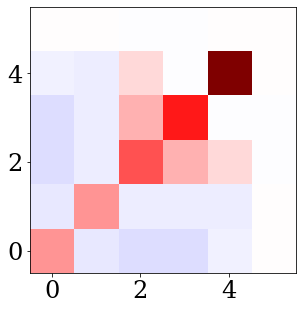

In [50]:
cov = np.linalg.inv(hessian)
vm = np.max(np.abs(cov))
plt.imshow(cov, cmap="seismic", vmax=vm, vmin=-vm)

In [51]:
chn = cc.Chain.from_covariance(fl, cov,names, "chain")

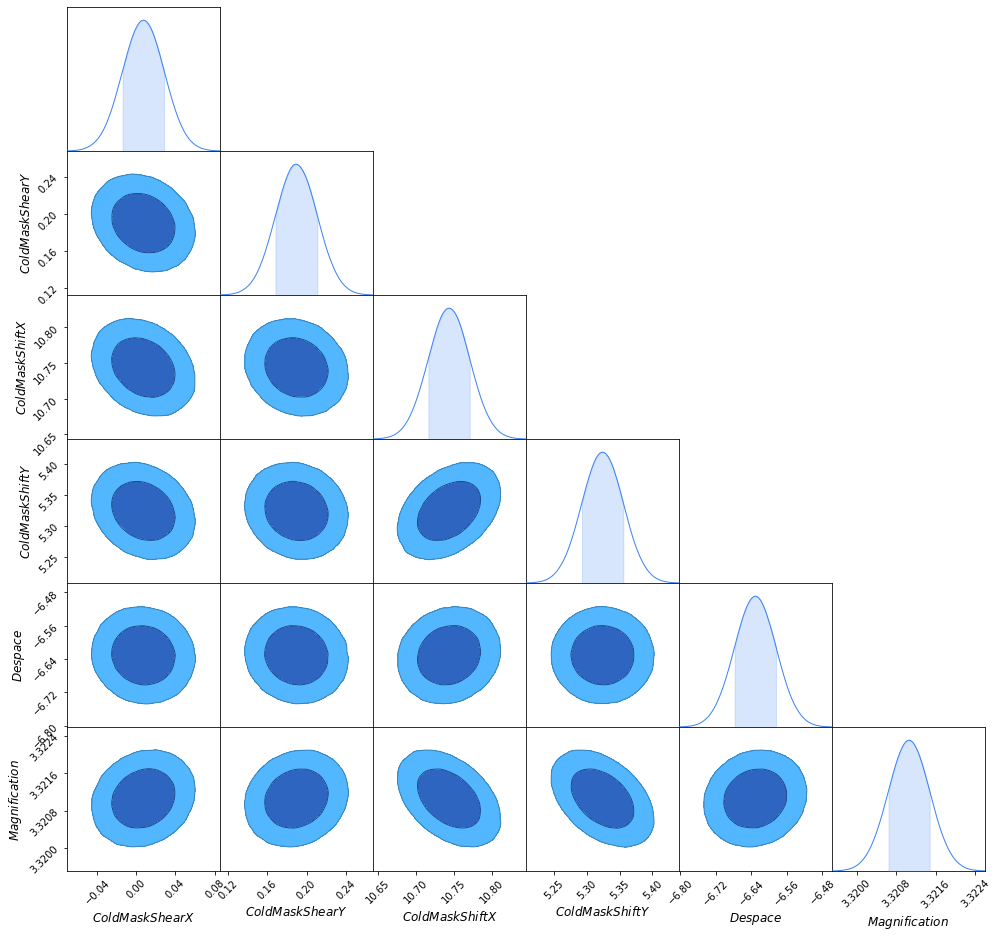

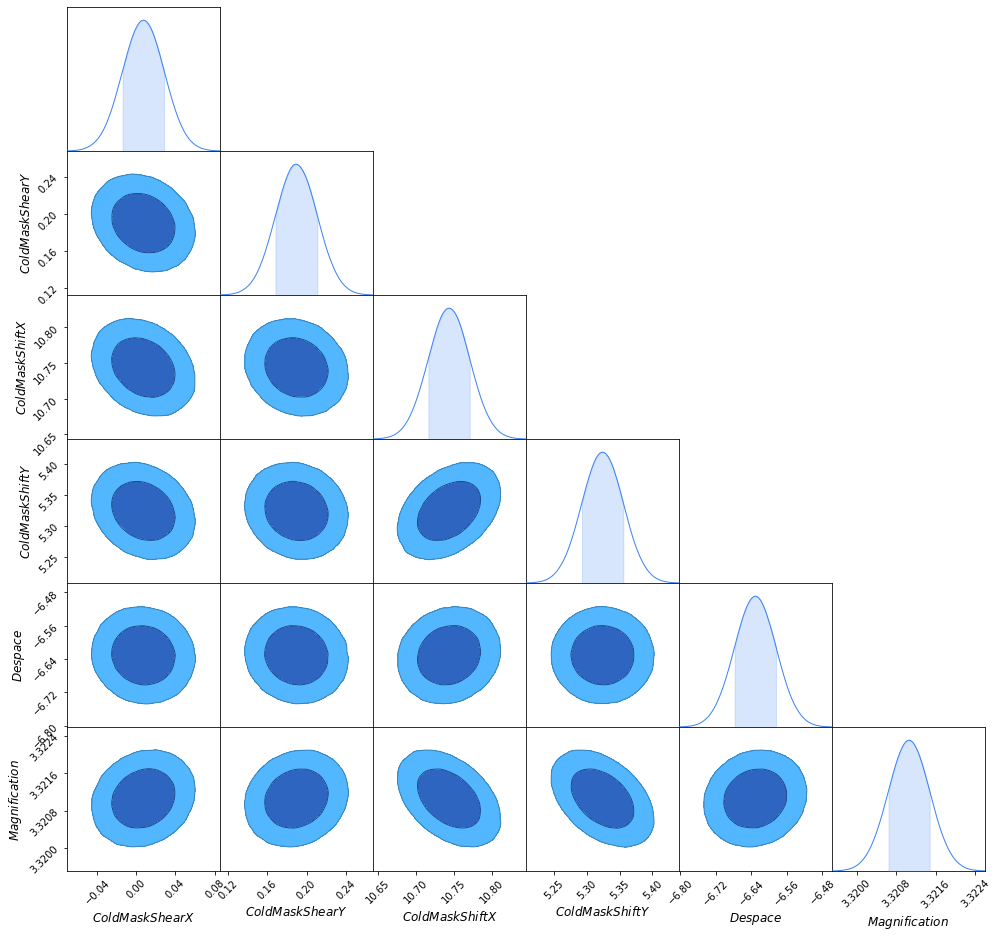

In [52]:
c = cc.ChainConsumer()
c.add_chain(chn)
c.set_plot_config(cc.PlotConfig(labels=labels, summarise=False))
c.plotter.plot()